In [11]:
from rdkit import Chem
from rdkit.Chem import Draw
from typing import List, Tuple, Optional
from rdkit.Chem.BRICS import FindBRICSBonds
import os
import random
from typing import Set

In [12]:
def get_backbone(frags_mol_lst: List[Chem.Mol], sdf_path: str) -> Optional[int]:
    """
    Return the fragment index with the most N-C=O substructure.
    """
    bond_smiles = "C(=O)N"
    max_match = 0
    idx = None
    
    for i, frag in enumerate(frags_mol_lst):
        matches = frag.GetSubstructMatches(Chem.MolFromSmarts(bond_smiles))
        if len(matches) > max_match:
            max_match = len(matches)
            idx = i

    if idx is None:
        print(f"Cannot find backbone. Please check inputs {sdf_path}")
    
    return idx

def get_backbone_cut_idx(mol: Chem.Mol, sdf_path: str) -> Tuple[List[int], List[Tuple[int, int]]]:
    """
    Identify the bonds between the alpha carbon and the nitrogen in the amino acid backbone.
    """
    bonds_to_break = []
    atom_bond_pairs = []

    for bond in mol.GetBonds():
        atom1, atom2 = bond.GetBeginAtom(), bond.GetEndAtom()
        if {atom1.GetSymbol(), atom2.GetSymbol()} == {"N", "C"}:
            carbon_atom = atom2 if atom1.GetSymbol() == "N" else atom1
            if any(neighbor.GetSymbol() == "O" and 
                   any(nb.GetBondType() == Chem.rdchem.BondType.DOUBLE for nb in neighbor.GetBonds())
                   for neighbor in carbon_atom.GetNeighbors()):
                bonds_to_break.append(bond.GetIdx())
                atom_bond_pairs.append((atom1.GetIdx(), atom2.GetIdx()))

    if not bonds_to_break:
        print(f"No valid backbone bonds found in the molecule, {Chem.MolToSmiles(mol)}, {sdf_path}")

    return bonds_to_break, atom_bond_pairs

def map_atom_indices(fragment, mol):
    return [mol.GetAtomWithIdx(int(atom.GetProp('orig_idx'))).GetIdx() for atom in fragment.GetAtoms()]

def fragmentize_by_bond(mol: Chem.Mol, bonds_to_break: List[int], sdf_path: str, FraSCESS: bool) -> Tuple[List[int], List[Chem.Mol]]:
    # for every atom in the molecule, mark its idx in the mol as a property for mapping
    for atom in mol.GetAtoms():
        print(atom.GetSymbol(), atom.GetIdx())
        atom.SetProp("orig_idx", str(atom.GetIdx()))

    all_bonds_to_break = set(bonds_to_break)

    if not bonds_to_break:
        print(f"Warning: No bonds to break in the peptide. Please check the input molecule {sdf_path}.")
        print(f"But we will try to proceed...")
        # Directly process by backbone_cut
        backbone_idx = get_backbone([mol], sdf_path)
        bonds_to_break_bk, _ = get_backbone_cut_idx(mol, sdf_path)
        if bonds_to_break_bk:
            mapping_atom = map_atom_indices(mol, mol)
            for bond_idx in bonds_to_break_bk:
                bond = mol.GetBondWithIdx(bond_idx)
                begin_atom_idx = mapping_atom[bond.GetBeginAtomIdx()]
                end_atom_idx = mapping_atom[bond.GetEndAtomIdx()]
                original_bond = mol.GetBondBetweenAtoms(begin_atom_idx, end_atom_idx)
                original_bond_idx = original_bond.GetIdx()
                all_bonds_to_break.add(original_bond_idx)
    else:
        # Break the bonds
        temp_mol = Chem.FragmentOnBonds(mol, bonds_to_break, addDummies=False)
        temp_mol_tuple = Chem.GetMolFrags(temp_mol, asMols=True)

        backbone_idx = get_backbone(temp_mol_tuple, sdf_path)
        
        for i, frag in enumerate(temp_mol_tuple):
            if i != backbone_idx:
                # set prop of the all atoms in the fragment
                for atom in frag.GetAtoms():
                    atom.SetProp("sidechain", str(i))
                brics_bonds = [frag.GetBondBetweenAtoms(i[0][0],i[0][1]).GetIdx() for i in FindBRICSBonds(frag)]
                if brics_bonds:
                    mapping_atom = map_atom_indices(frag, mol)
                    # print(brics_bonds)
                    for bond_idx in brics_bonds:
                        bond = frag.GetBondWithIdx(bond_idx)
                        begin_atom_idx = mapping_atom[bond.GetBeginAtomIdx()]
                        end_atom_idx = mapping_atom[bond.GetEndAtomIdx()]
                        original_bond = mol.GetBondBetweenAtoms(begin_atom_idx, end_atom_idx)
                        original_bond_idx = original_bond.GetIdx()
                        all_bonds_to_break.add(original_bond_idx)
                else:
                    # Randomly break bonds until fragment is divided into at least two substructures
                    if FraSCESS:
                        fragmentize_sidechain(frag, mol, all_bonds_to_break)

        for j, frag in enumerate(temp_mol_tuple):
            if j == backbone_idx:
                # set prop of the all atoms in the fragment
                for atom in frag.GetAtoms():
                    atom.SetProp("backbone", str(j))
                bonds_to_break_bk, _ = get_backbone_cut_idx(frag, sdf_path)
                if bonds_to_break_bk:
                    mapping_atom = map_atom_indices(frag, mol)
                    for bond_idx in bonds_to_break_bk:
                        bond = frag.GetBondWithIdx(bond_idx)
                        begin_atom_idx = mapping_atom[bond.GetBeginAtomIdx()]
                        end_atom_idx = mapping_atom[bond.GetEndAtomIdx()]
                        original_bond = mol.GetBondBetweenAtoms(begin_atom_idx, end_atom_idx)
                        original_bond_idx = original_bond.GetIdx()
                        all_bonds_to_break.add(original_bond_idx)

    return all_bonds_to_break

def fragmentize_sidechain(frag: Chem.Mol, mol: Chem.Mol, all_bonds_to_break: set, seed: int = 42):
    # print(Chem.MolToSmiles(frag))
    random.seed(seed)
    bonds = []
    for bond in frag.GetBonds():
        if bond.GetBondType() == Chem.BondType.SINGLE:
            bonds.append(bond.GetIdx())

    if not bonds:
        return

    mapping_atom = map_atom_indices(frag, mol)

    while bonds:
        bond_idx_frag = random.choice(bonds)
        bond_in_frag = frag.GetBondWithIdx(bond_idx_frag)
        begin_atom_idx_frag = bond_in_frag.GetBeginAtomIdx()
        end_atom_idx_frag = bond_in_frag.GetEndAtomIdx()

        original_bond = mol.GetBondBetweenAtoms(mapping_atom[begin_atom_idx_frag], mapping_atom[end_atom_idx_frag])

        # to make sure that the bond is not neighboring any bonds in all_bonds_to_break
        # get the terminal atoms of the bond in the original molecule
        begin_atom_idx_ori = original_bond.GetBeginAtom().GetIdx()
        end_atom_idx_ori = original_bond.GetEndAtom().GetIdx()
        # get the bonds of the terminal atoms
        begin_atom_bonds = [bond.GetIdx() for bond in mol.GetAtomWithIdx(begin_atom_idx_ori).GetBonds()]
        end_atom_bonds = [bond.GetIdx() for bond in mol.GetAtomWithIdx(end_atom_idx_ori).GetBonds()]
        # check if any of the terminal atoms' bonds are in all_bonds_to_break
        if any(bond_idx in all_bonds_to_break for bond_idx in begin_atom_bonds) or any(bond_idx in all_bonds_to_break for bond_idx in end_atom_bonds):
            bonds.remove(bond_idx_frag)
            continue

        # get original bond idx
        bond_idx_ori = original_bond.GetIdx()
        
        # Ensure the selected bond does not reconnect the initial split atoms
        if bond_idx_ori not in all_bonds_to_break:
            all_bonds_to_break.add(bond_idx_ori)
            
            temp_frag = Chem.FragmentOnBonds(frag, [bond_idx_frag], addDummies=False)
            try:
                frag_tuple = Chem.GetMolFrags(temp_frag, asMols=True)
            except Chem.rdchem.KekulizeException as e:
                print(f"Error: {e}")
                print(f"Fragment: {Chem.MolToSmiles(frag)}")
                print(f"Molecule: {Chem.MolToSmiles(mol)}")
                # print each atom and its idx
                for atom in frag.GetAtoms():
                    print(atom.GetSymbol(), atom.GetIdx())
                # print each bond and terminal atoms, bond type, bond idx
                for bond in frag.GetBonds():
                    print(bond.GetBeginAtom().GetSymbol(), bond.GetEndAtom().GetSymbol(), bond.GetBondType(), bond.GetIdx())
                print(f"Bond to break: {bond_idx_frag}, terminal atom symbols: {frag.GetAtomWithIdx(begin_atom_idx_frag).GetSymbol()}, {frag.GetAtomWithIdx(end_atom_idx_frag).GetSymbol()}")
                print(f"Bond to break type: {bond_in_frag.GetBondType()}")
                raise e
            # print(frag_tuple)
            
            if len(frag_tuple) > 1:
                break

            bonds.remove(bond_idx_frag)
        else:
            # print(f"Warning: Bond {bond_idx} is in all_bonds_to_break.")
            bonds.remove(bond_idx_frag)

def get_bond_by_prop(mol: Chem.Mol) -> Tuple[List[int], List[Tuple[int, int]]]:
    """
    Break bonds in a molecule by a property 'LinkingBond'.
    """
    bonds_to_break = [bond.GetIdx() for bond in mol.GetBonds() if bond.HasProp("LinkingBond")]
    atom_bond_atom = [(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()) for bond in mol.GetBonds() if bond.HasProp("LinkingBond")]
    return bonds_to_break, atom_bond_atom

def load_SDF_directory(directory: str) -> List[str]:
    sdf_file_paths = [os.path.join(root, file) for root, _, files in os.walk(directory) for file in files if file.endswith(".sdf")]
    
    if not sdf_file_paths:
        raise ValueError(f"No SDF files found in {directory}")
    
    print(f"Loaded {len(sdf_file_paths)} SDF files in {directory}")
    return sdf_file_paths

def read_SDF_file(file_path: str) -> Chem.Mol:
    if not os.path.exists(file_path):
        raise ValueError("File path does not exist")
    
    suppl = Chem.SDMolSupplier(file_path)
    for mol in suppl:
        if mol is None:
            continue
        if mol.HasProp("_BondProps"):
            bond_props = mol.GetProp("_BondProps").split('|')
            for prop in bond_props:
                idx, value = prop.split(':')
                bond = mol.GetBondWithIdx(int(idx))
                bond.SetProp("LinkingBond", value)
        return mol

    raise ValueError("No valid molecule found in the SDF file")

def sdf_to_mol(sdf_file_paths: List[str]) -> List[Tuple[str, Chem.Mol]]:
    return [(sdf, read_SDF_file(sdf)) for sdf in sdf_file_paths]

def get_fragment_feats(mol: Chem.Mol, sdf_path: str = None, F=False) -> Tuple[List[int], List[Chem.Mol]]:
    bonds_to_break, _ = get_bond_by_prop(mol)
    return fragmentize_by_bond(mol, bonds_to_break, sdf_path, FraSCESS=F)

In [13]:
sdf_file_paths = load_SDF_directory("./testmol")
mols = sdf_to_mol(sdf_file_paths)

# print smiles of the molecule
for sdf, mol in mols:
    print(sdf, Chem.MolToSmiles(mol))

Loaded 12 SDF files in ./testmol
./testmol\DBAASPN_18206_Brevicidine_B_4_Me_C6.sdf CC[C@H](C)[C@H](NC(=O)[C@@H](NC(=O)[C@H](Cc1c[nH]c2ccccc12)NC(=O)[C@@H](CCCN)NC(=O)CNC(=O)[C@H](CCCN)NC(=O)[C@@H](CCCN)NC(=O)[C@@H](Cc1c[nH]c2ccccc12)NC(=O)[C@@H](Cc1ccccc1)NC(=O)[C@H](N)CC(N)=O)[C@@H](C)O)C(=O)NCC(=O)N[C@@H](CO)C(=O)O
./testmol\DBAASPS_13056_Cathelicidin_1__C3ALA_pen__I5_8R__V6_10L__V7ALA_pen__C11L___Bac2A__A3ALA_pen__I5_8R__V6_10L__V7ALA_pen__A11L__AMD.sdf C=CCCC[C@](C)(NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@](C)(CCCC=C)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](N)CCCNC(=N)N)C(=O)N[C@@H](CCCNC(=N)N)C(=O)N[C@@H](CCCNC(=N)N)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCCNC(=N)N)C(N)=O
./testmol\DBAASPS_11797_Chex1_Arg20__R20MeR__AMD.sdf CC(C)C[C@H](NC(=O)[C@H](Cc1ccc(O)cc1)NC(=O)[C@@H]1CCCN1C(=O)[C@H](CCCNC(=N)N)NC(=O)[C@@H]1CCCN1C(=O)[C@H](CCCCN)NC(=O)[C@H](CC(=O)O)NC(=O)[C@@H]1CCCN1C(=O)[C@H](CCCNC(=N)N)NC(=O)C1(N)CCCCC1)C(=O)N1CCC[C@H]1C(=O)N[C@@H](CCC

C 0
C 1
C 2
O 3
N 4
C 5
O 6
N 7
C 8
C 9
C 10
C 11
C 12
C 13
C 14
C 15
C 16
O 17
N 18
C 19
C 20
C 21
C 22
C 23
C 24
C 25
C 26
N 27
C 28
C 29
C 30
O 31
N 32
C 33
C 34
C 35
C 36
O 37
N 38
C 39
N 40
C 41
C 42
C 43
C 44
O 45
N 46
C 47
N 48
C 49
C 50
O 51
N 52
C 53
C 54
C 55
C 56
O 57
N 58
C 59
N 60
C 61
C 62
C 63
C 64
C 65
C 66
C 67
C 68
N 69
C 70
C 71
C 72
O 73
N 74
C 75
C 76
C 77
C 78
O 79
N 80
O 81
C 82
C 83
C 84
C 85
C 86
C 87
O 88
N 89
C 90
C 91
O 92
N 93
C 94
C 95
C 96
O 97
O 98
N 99
O 100
{0, 6, 13, 18, 28, 34, 36, 41, 42, 44, 49, 50, 54, 56, 61, 62, 72, 78, 80, 85, 86, 89, 93, 97, 98, 104}
[{0, 6, 13, 18, 28, 34, 36, 41, 42, 44, 49, 50, 54, 56, 61, 62, 72, 78, 80, 85, 86, 89, 93, 97, 98, 104}]
O 0
C 1
C 2
C 3
C 4
C 5
N 6
C 7
N 8
N 9
N 10
C 11
C 12
C 13
C 14
C 15
C 16
O 17
N 18
C 19
C 20
C 21
C 22
C 23
C 24
C 25
C 26
O 27
N 28
O 29
C 30
C 31
C 32
C 33
C 34
N 35
C 36
N 37
N 38
N 39
O 40
C 41
C 42
C 43
C 44
C 45
N 46
C 47
N 48
N 49
N 50
C 51
C 52
C 53
C 54
C 55
C 56
O 57
N 58
C 59
C 60

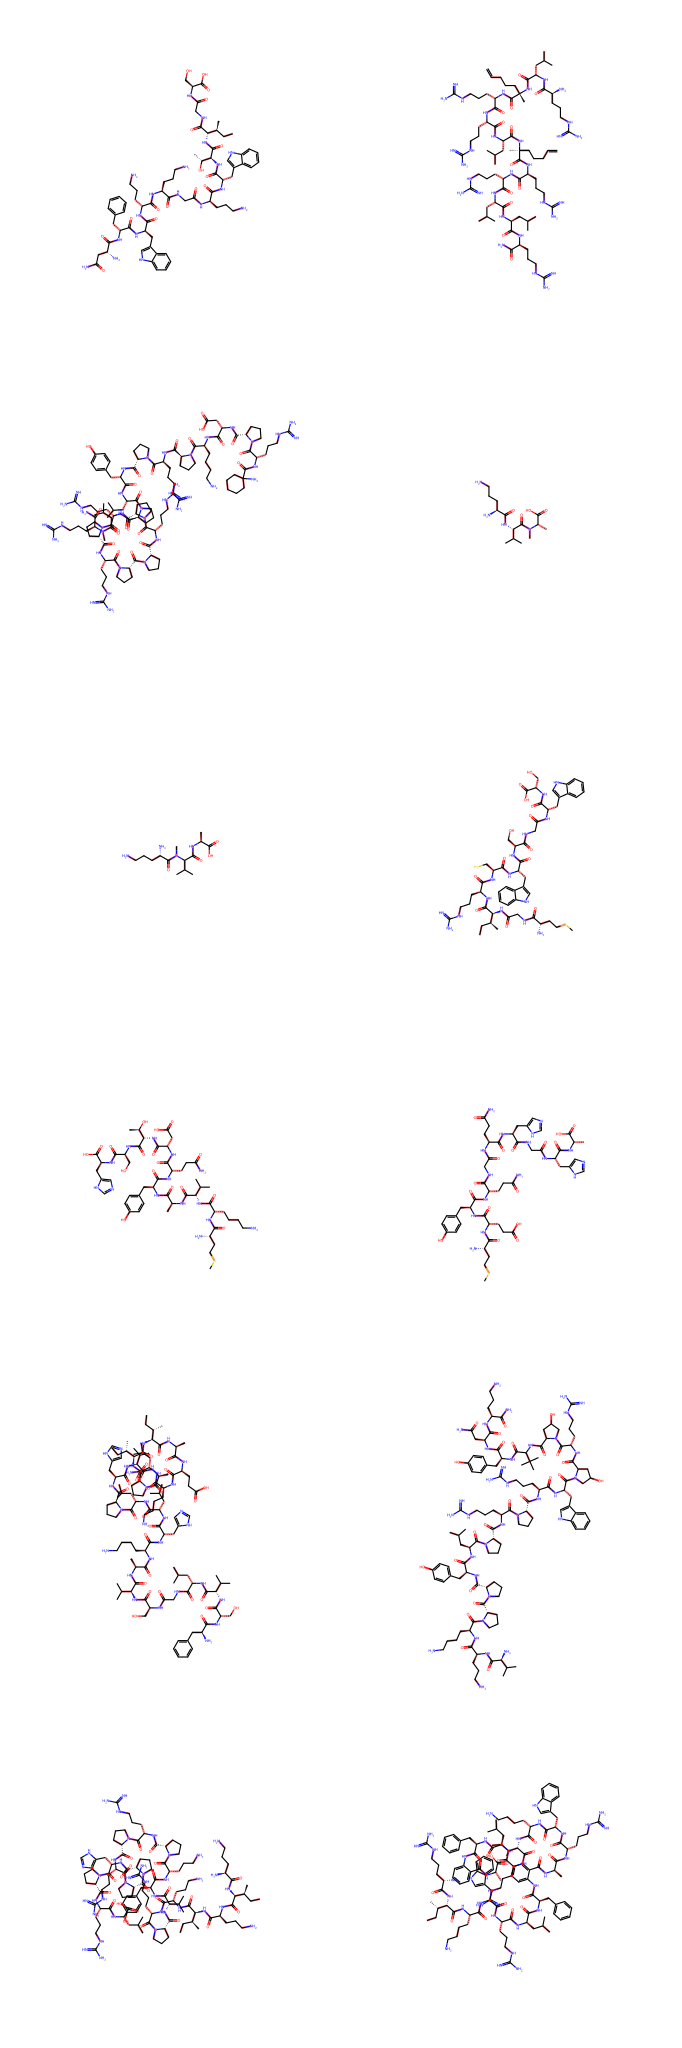

In [14]:
all_bonds_to_break_list = []
for sdf_path, mol in mols:
    all_bonds_to_break = get_fragment_feats(mol, sdf_path=sdf_path, F=True)
    print(all_bonds_to_break)
    temp_mol = Chem.FragmentOnBonds(mol, all_bonds_to_break, addDummies=False)
    all_bonds_to_break_list.append(all_bonds_to_break)
    print(all_bonds_to_break_list)
    # fragment_idx_list contains the indices of the atoms in each fragment.
    # fragment_idx_list = Chem.GetMolFrags(temp_mol) # List of fragmentized molecules by index
    # fragment_mol_list contains the individual fragment molecules.
    # fragment_mol_list = Chem.GetMolFrags(temp_mol, asMols=True) # List of fragmentized molecules

Draw.MolsToGridImage([mol for _, mol in mols], molsPerRow=2, subImgSize=(600, 600), highlightAtomLists=None, highlightBondLists=all_bonds_to_break_list, useSVG=True)

In [15]:
from rdkit.Chem import MACCSkeys

def maccskeys_emb(mol):
    return list(MACCSkeys.GenMACCSKeys(mol))

frag_dict = {
    "frequent_fragments": {
        "CO": 0,
        "NCC=O": 1,
        "Cc1c[nH]c2ccccc12": 2,
        "c1ccccc1": 3,
        "C": 4,
        "O": 5,
        "Cc1ccccc1": 6,
        "CC": 7,
        "CCN": 8,
        "CC=O": 9,
        "N": 10,
        "NCC(=O)O": 11,
        "CCC": 12,
        "Cc1cnc[nH]1": 13}}

# calculate MACCS keys for each fragment in frag_dict
for frag in frag_dict["frequent_fragments"].keys():
    mol = Chem.MolFromSmiles(frag)
    print(frag, maccskeys_emb(mol))

CO [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0]
NCC=O [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0,

In [16]:
for frag in frag_dict["frequent_fragments"].keys():
    mol = Chem.MolFromSmiles(frag)
    for atom in mol.GetAtoms():
        print(atom.GetSymbol(), atom.GetIdx())

C 0
O 1
N 0
C 1
C 2
O 3
C 0
C 1
C 2
N 3
C 4
C 5
C 6
C 7
C 8
C 9
C 0
C 1
C 2
C 3
C 4
C 5
C 0
O 0
C 0
C 1
C 2
C 3
C 4
C 5
C 6
C 0
C 1
C 0
C 1
N 2
C 0
C 1
O 2
N 0
N 0
C 1
C 2
O 3
O 4
C 0
C 1
C 2
C 0
C 1
C 2
N 3
C 4
N 5
